17


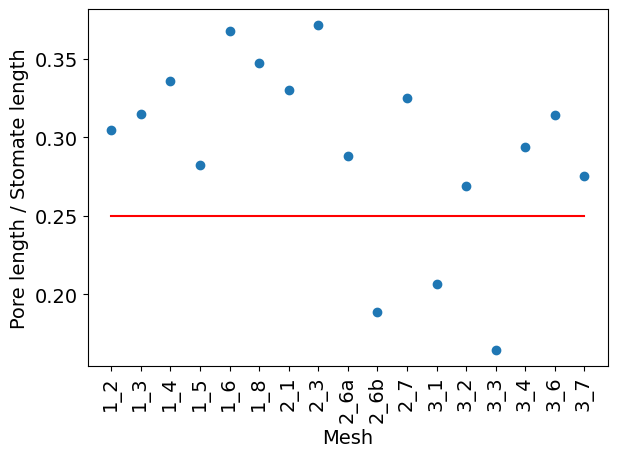

Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


In [258]:
## Load in the confocal data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Results dataframes
confocal_df = pd.read_csv("confocal_results_df_batch.csv")
idealised_df = pd.read_csv("idealised_chosen_results.csv")

## Set the colours for the three mesh types
colours = {
    'realistic': 'magenta',
    'anisotropic': "#8A0CA1",
    'simplified_circular': 'orange',
    'simplified_oval': 'green',
    'midsection' : 'black',
    'tip' : "#CC79A7"
}

# Set the default font size for all plots
plt.rcParams.update({'font.size': 14})

## Set the name for each mesh
mesh_dcr = "Sample"

## Choose meshes to include based on their pore length : length
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

plt.plot(mesh_ids, pore_proportion, 'o')
xs = np.arange(0,len(stomata_length))
ys = np.ones(len(xs)) * 0.25
plt.plot(xs,ys,'r-')

plt.xlabel('Mesh')
plt.ylabel('Pore length / Stomate length')
plt.xticks(rotation=90)
plt.tight_layout() 
plt.savefig("mesh_selection.png")
plt.show()

## Based on this plot, let's take a threshold of 0.25

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)


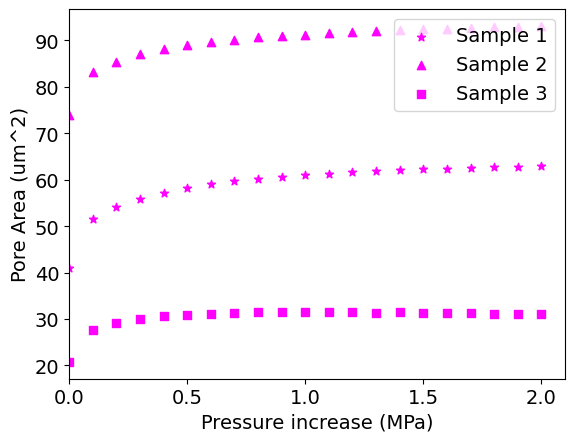

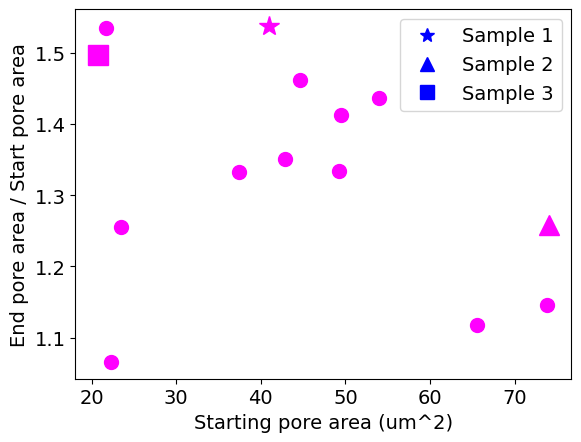

In [259]:
## Figure 1: FEM models of stomata using realistic geometry open without anisotropic stiffening or polar pinning
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

sample_meshes = ["1_2","2_3","3_2"]
all_meshes = confocal_df["Mesh ID"].unique()
number_of_samples = 3
mesh_names = [mesh_dcr + " " + str(s) for s in np.arange(1, number_of_samples + 1)]
symbols = ["*","^","s"]

## Plot pressure vs pore area for each of the sample meshes
for mesh, symbol, mesh_name in zip(sample_meshes, symbols, mesh_names):
    data = confocal_df[confocal_df["Mesh ID"] == mesh]
    plt.scatter(data["Pressure"],data["Pore Area"], marker=symbol, label=mesh_name, color = colours["realistic"])
plt.xlabel("Pressure increase (MPa)")
plt.ylabel("Pore Area (um^2)")
plt.xlim(0,2.1)
plt.legend(loc='upper right')
plt.savefig("confocal_pressure_pore_area.png", dpi=300)
plt.show()

## Plot starting pore area vs end pore area / start pore area. Highlight the three selected meshes
for mesh in selected_meshes:
    data = confocal_df[confocal_df["Mesh ID"]==mesh]
    start_pore = data[data["Pressure"]==0.0]["Pore Area"].values
    end_pore = data[data["Pressure"]==2.0]["Pore Area"].values
    if mesh == sample_meshes[0]: 
        marker = symbols[0]
        size = 15
    elif mesh == sample_meshes[1]: 
        marker = symbols[1]
        size = 15
    elif mesh == sample_meshes[2]: 
        marker = symbols[2]
        size = 15
    else: 
        marker = "o"
        size = 10

    plt.plot(start_pore, end_pore/start_pore,marker=marker, color = colours['realistic'], markersize = size)
    legend_elements = []
    for name, symbol in zip(mesh_names, symbols):
        legend_elements.append(Line2D([0], [0], marker=symbol, color='blue', label=name, markersize=10, linestyle='None'))

plt.legend(handles=legend_elements, loc='upper right')
plt.xlabel("Starting pore area (um^2)")
plt.ylabel("End pore area / Start pore area")
plt.savefig("confocal_change_pore_area.png", dpi=300)
plt.show()

In [260]:
## Function to get the cross section of the idealised mesh at the midpoint
def extract_midpoint_cross_section(mesh, guard_cell="left"):
    """
    Extract a midpoint cross-section and return a list with one (N,3) float array,
    ordered consistently. Uses wall-centre helpers when possible, else falls back
    to PCA-based midplane slicing.
    """
    import numpy as np
    import cross_section_helpers as csh
    from sklearn.decomposition import PCA

    def _order_and_validate(pts, normal, midpoint):
        pts = np.asarray(pts, dtype=float)
        if pts.ndim != 2 or pts.shape[1] != 3 or pts.shape[0] < 3:
            raise ValueError(f"Selected section invalid shape {pts.shape}; expected (N,3) with N>=3.")
        ordered = csh.order_points_consistently(pts, normal=normal, midpoint=midpoint)
        return [ordered.astype(float)]

    # Try robust wall-based method
    try:
        wall_vertices = csh.find_wall_vertices(mesh)
        if wall_vertices.size == 0:
            wall_vertices = csh.find_wall_vertices_vertex_normals(mesh)
        if wall_vertices.size > 0:
            centre_top, centre_bottom, *_ = csh.get_top_bottom_wall_centres(mesh, wall_vertices)
            midpoint, _traces, section_points, local_axes = csh.get_midpoint_cross_section_from_centres(
                mesh, centre_top, centre_bottom
            )
            if section_points is None or len(section_points) < 3:
                raise RuntimeError("Midpoint cross-section failed (insufficient points)")
            left_section, right_section, *_ = csh.get_left_right_midsections(section_points, midpoint, local_axes)
            pts = left_section if guard_cell == "left" else right_section
            wall_vec = local_axes[0]
            return _order_and_validate(pts, normal=wall_vec, midpoint=midpoint)
    except Exception:
        # Fall back to PCA-based method
        pass

    # Fallback: PCA-based midplane perpendicular to longest axis
    verts = np.asarray(mesh.vertices, dtype=float)
    if verts.shape[0] < 3:
        raise ValueError("Mesh has too few vertices to compute a cross-section.")

    p = PCA(n_components=3).fit(verts)
    longest_axis = p.components_[0]
    # Project onto plane orthogonal to longest axis through mesh centroid
    centroid = verts.mean(axis=0)

    # Take section using trimesh.section
    section = mesh.section(plane_origin=centroid, plane_normal=longest_axis)
    if section is None:
        raise ValueError("Fallback sectioning failed: no intersection with midplane.")

    # Convert section to dense points
    if hasattr(section, 'discrete') and section.discrete:
        section_points = np.vstack([seg for seg in section.discrete if len(seg) > 0])
    else:
        section_points = np.asarray(section.vertices, dtype=float)

    if section_points is None or len(section_points) < 3:
        raise ValueError("Fallback section produced insufficient points (<3).")

    # Build local axes: wall_vec ~ longest_axis, left_right_vec via PCA in plane
    # Use PCA on section points to get principal directions in the section plane
    p2 = PCA(n_components=2).fit(section_points)
    left_right_vec = p2.components_[0]
    wall_vec = longest_axis / (np.linalg.norm(longest_axis) + 1e-12)

    # Midpoint for ordering/splitting
    midpoint = section_points.mean(axis=0)

    # Split into left/right using projection on left_right_vec
    rel = section_points - midpoint
    proj = rel @ left_right_vec
    left_section = section_points[proj < 0]
    right_section = section_points[proj >= 0]

    pts = left_section if guard_cell == "left" else right_section
    return _order_and_validate(pts, normal=wall_vec, midpoint=midpoint)

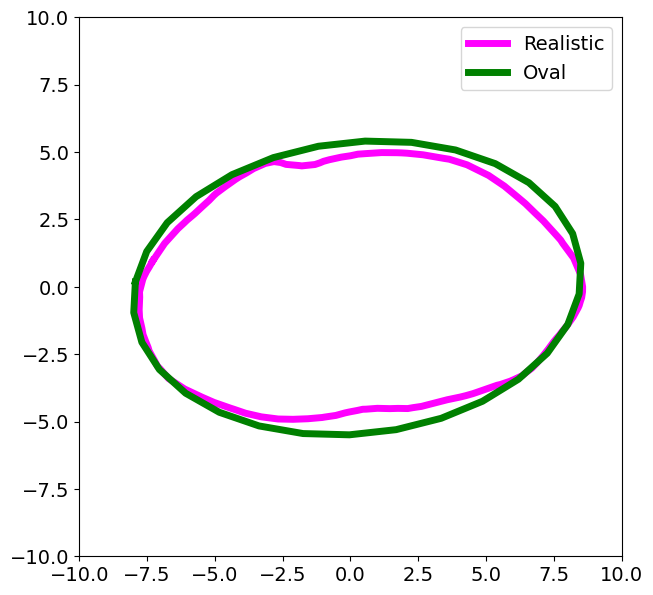

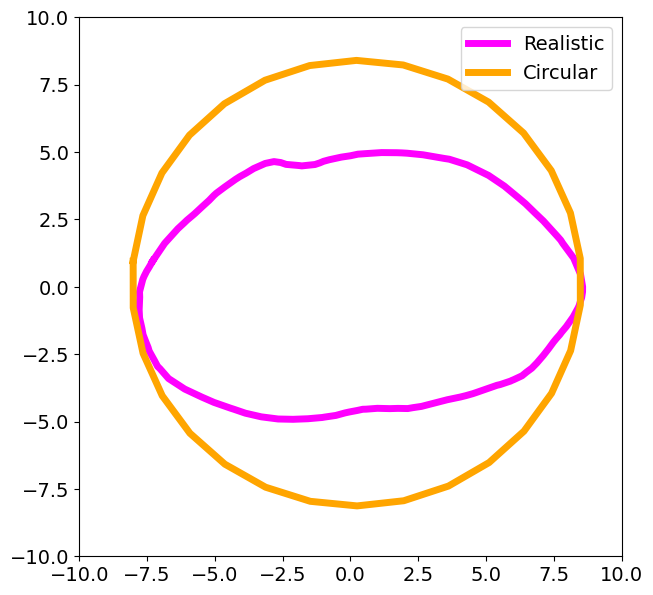

In [261]:
## Create side by side and cross section views of each mesh
import sys
from pathlib import Path
import importlib
import numpy as np
import ast
import re
# Add parent directory to sys.path
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import cross_section_helpers as csh
importlib.reload(csh)
import trimesh

oval_path = "../Meshes/Idealised/idealised_final_1_2_oval.ply"
circular_path = "../Meshes/Idealised/idealised_final_1_2_circular.ply"
idealised_oval_mesh = trimesh.load_mesh(oval_path)
idealised_circular_mesh = trimesh.load_mesh(circular_path)

confocal_df_sample = confocal_df[(confocal_df["Mesh ID"] == "1_2") & (confocal_df["Pressure"]==0.0)].copy()
## Get the cross section list (each entry is (N,3)) for the oval idealised mesh, left guard cell
idealised_oval_sections_left = extract_midpoint_cross_section(idealised_oval_mesh, guard_cell="left")
idealised_circular_sections_left = extract_midpoint_cross_section(idealised_circular_mesh, guard_cell="left")

# Preprocess the strings to ensure proper formatting for confocal (kept for later usage)
confocal_df_sample["Midsection Points Left"] = confocal_df_sample["Midsection Points Left"].apply(
    lambda x: re.sub(r',\s*\]', ']', re.sub(r'\[\s*,', '[', re.sub(r'\s+', ',', x)))
)
confocal_df_sample["Midsection Points Left"] = confocal_df_sample["Midsection Points Left"].apply(lambda x: np.array(ast.literal_eval(x)))

## Plot the cross section(s). We pass lists for both inputs per helper's contract
csh.plot_cross_sections_grid_overlay(list(confocal_df_sample["Midsection Points Left"]), idealised_oval_sections_left, n_cols=1, figsize=(7, 7), colors=(colours["realistic"], colours["simplified_oval"]), filename="cross_section_oval.png", linewidth = 5, ylim=10, mesh1 = "Realistic", mesh2 = "Oval")
csh.plot_cross_sections_grid_overlay(list(confocal_df_sample["Midsection Points Left"]), idealised_circular_sections_left, n_cols=1, figsize=(7, 7), colors=(colours["realistic"], colours["simplified_circular"]), filename="cross_section_circular.png", linewidth=5, ylim=10,mesh1 = "Realistic", mesh2 = "Circular")

In [262]:
## Figure 2: Show the complexity of stomata through analysis of their cross sections and how there is a difference between the cross sections at the midpoint and the tip.
## Show the cross sections within a mesh. Highlight the tip and the midsection. Show the boxplots of midsection and tip. Link the points.
import trimesh
import importlib
importlib.reload(csh)
from cross_section_helpers import visualize_mesh, analyze_stomata_mesh
import plotly.graph_objects as go

## Select mesh for visualisation
mesh_to_visualise = "1_2"
meshfile = f"../Meshes/Onion_OBJ/Ac_DA_{mesh_to_visualise}.obj"
mesh = trimesh.load(meshfile, force='mesh')

## Get the cross sections
section_points_right, section_points_left, section_traces_left, section_traces_right, _ = analyze_stomata_mesh(meshfile)

## Get the tip and midsection cross sections
tip = section_traces_left[0]
mid_index = len(section_traces_left) // 2
midsection = section_traces_left[mid_index]

## Make new traces, thinner lines and more opacity. Choose a palette suitable for colour blindness
section_traces = []
for section in section_points_left:
    trace = go.Scatter3d(
        x=section[:, 0],  # X-coordinates
        y=section[:, 1],  # Y-coordinates
        z=section[:, 2],  # Z-coordinates
        mode='lines',     # Line mode
        line=dict(width=5, color="#F0E442"),  # Thinner line
        name='Cross-section',
        opacity=0.5       # More opacity
    )
    section_traces.append(trace)
tip = section_points_left[0]
mid_index = len(section_points_left) // 2
midsection = section_points_left[mid_index]

midsection_trace = go.Scatter3d(
    x=midsection[:,0],  # X-coordinate
    y=midsection[:,1],  # Y-coordinate
    z=midsection[:,2],  # Z-coordinate
    mode='lines',     # Only markers
    line=dict(width=10, color=colours["midsection"]),  # Marker style
    name='Midsection',
    opacity=1         # Legend name
)
tip_trace = go.Scatter3d(
    x=tip[:,0],  # X-coordinate
    y=tip[:,1],  # Y-coordinate
    z=tip[:,2],  # Z-coordinate
    mode='lines',     # Only markers
    line=dict(width=10, color=colours["tip"]),  # Thinner line
    name='Tip',
    opacity=1         # Legend name
)

output = visualize_mesh(mesh, [tip_trace, midsection_trace] + section_traces )
output.write_html("mesh_with_cross_sections.html")


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

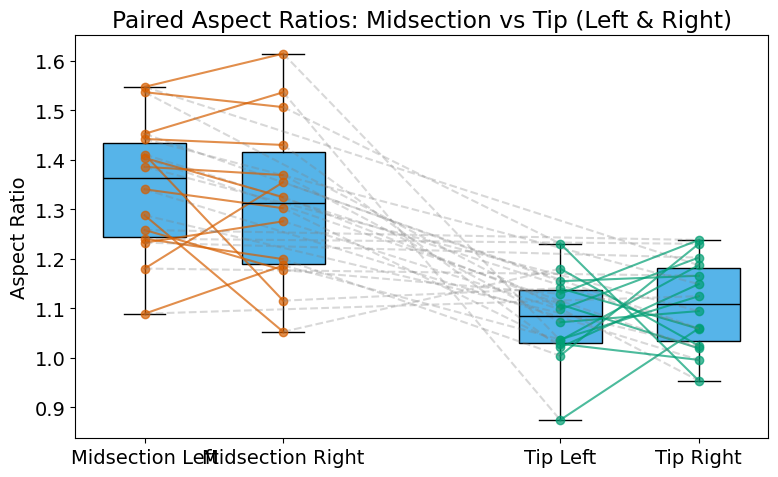

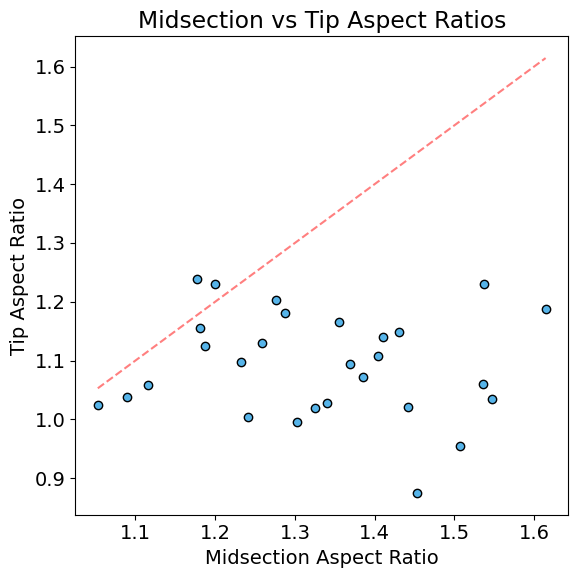

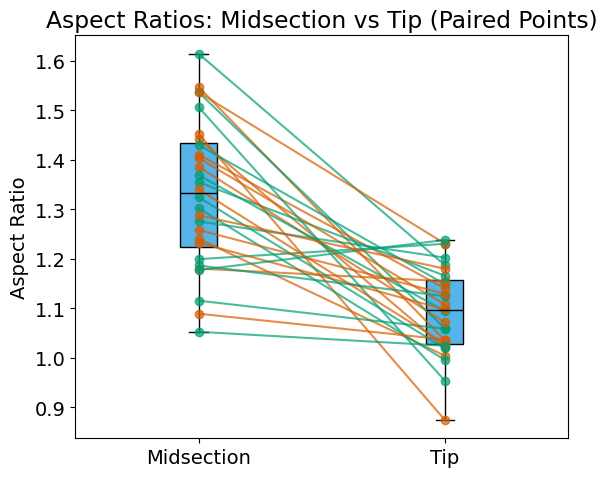

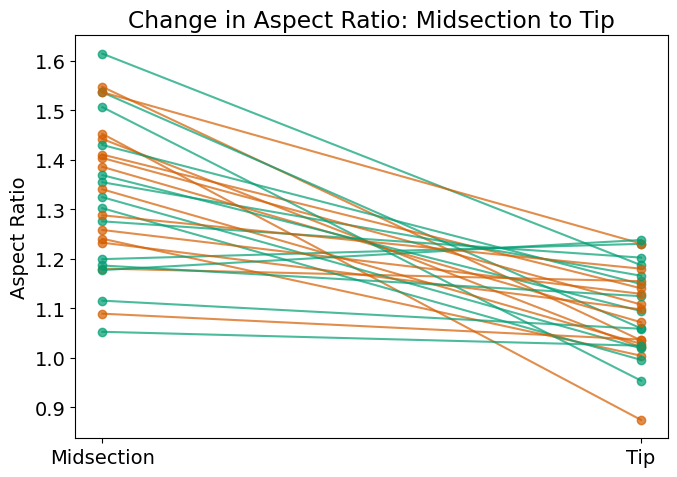

In [263]:
## Tip and midsection box plots for Figure 2

df_box = confocal_df[(confocal_df["Pressure"]==0) & (confocal_df["Mesh ID"].isin(selected_meshes))]

mid_left = df_box['Midsection AR left']
mid_right = df_box['Midsection AR right']
tip_left = df_box['Tip AR left']
tip_right = df_box['Tip AR right']

# Combine for boxplot
box_data = [mid_left, mid_right, tip_left, tip_right]
labels = ['Midsection Left', 'Midsection Right', 'Tip Left', 'Tip Right']

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(box_data, positions=[1,2,4,5], widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='#56B4E9'), medianprops=dict(color='black'))

# Connect paired values for each mesh
for idx in range(len(df_box)):
    ax.plot([1,2], [mid_left.iloc[idx], mid_right.iloc[idx]], color='#D55E00', alpha=0.7, marker='o')
    ax.plot([4,5], [tip_left.iloc[idx], tip_right.iloc[idx]], color='#009E73', alpha=0.7, marker='o')
    # Optionally connect midsection to tip for each side:
    ax.plot([2,4], [mid_right.iloc[idx], tip_left.iloc[idx]], color='gray', alpha=0.3, linestyle='--')
    ax.plot([1,5], [mid_left.iloc[idx], tip_right.iloc[idx]], color='gray', alpha=0.3, linestyle='--')

ax.set_xticks([1,2,4,5])
ax.set_xticklabels(labels)
ax.set_ylabel('Aspect Ratio')
ax.set_title('Paired Aspect Ratios: Midsection vs Tip (Left & Right)')
plt.tight_layout()
plt.show()

mid_all = pd.concat([df_box['Midsection AR left'], df_box['Midsection AR right']])
tip_all = pd.concat([df_box['Tip AR left'], df_box['Tip AR right']])

plt.figure(figsize=(6,6))
plt.scatter(mid_all, tip_all, color='#56B4E9', edgecolor='black')
plt.xlabel('Midsection Aspect Ratio')
plt.ylabel('Tip Aspect Ratio')
plt.title('Midsection vs Tip Aspect Ratios')
plt.plot([mid_all.min(), mid_all.max()], [mid_all.min(), mid_all.max()], 'r--', alpha=0.5)  # Diagonal reference
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.boxplot([mid_all, tip_all], tick_labels=['Midsection', 'Tip'], patch_artist=True,
            boxprops=dict(facecolor='#56B4E9'), medianprops=dict(color='black'))

# Overlay paired points
for i in range(len(df_box)):
    plt.plot([1,2], [df_box['Midsection AR left'].iloc[i], df_box['Tip AR left'].iloc[i]], 'o-', color='#D55E00', alpha=0.7)
    plt.plot([1,2], [df_box['Midsection AR right'].iloc[i], df_box['Tip AR right'].iloc[i]], 'o-', color='#009E73', alpha=0.7)

plt.ylabel('Aspect Ratio')
plt.title('Aspect Ratios: Midsection vs Tip (Paired Points)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
for i in range(len(df_box)):
    plt.plot([1,2], [df_box['Midsection AR left'].iloc[i], df_box['Tip AR left'].iloc[i]], 'o-', color='#D55E00', alpha=0.7)
    plt.plot([1,2], [df_box['Midsection AR right'].iloc[i], df_box['Tip AR right'].iloc[i]], 'o-', color='#009E73', alpha=0.7)

plt.xticks([1,2], ['Midsection', 'Tip'])
plt.ylabel('Aspect Ratio')
plt.title('Change in Aspect Ratio: Midsection to Tip')
plt.tight_layout()
plt.show()


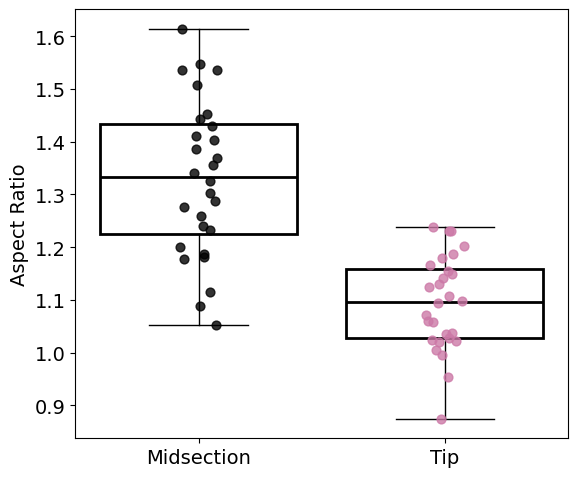

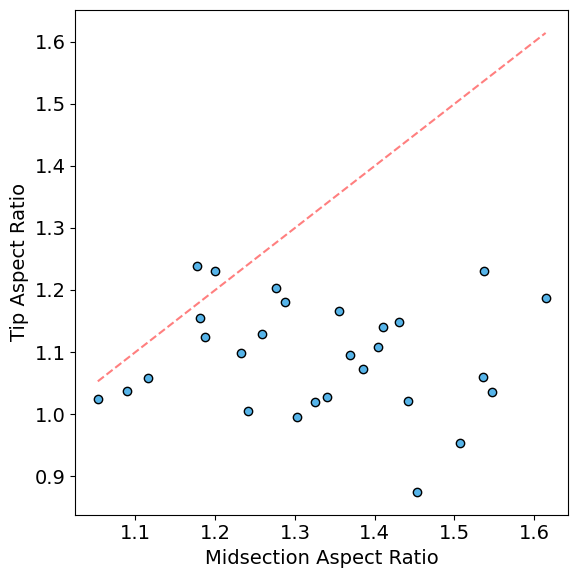

In [264]:
import matplotlib.pyplot as plt

# Concatenate left and right aspect ratios for midsection and tip
import matplotlib.pyplot as plt

mid_all = pd.concat([df_box['Midsection AR left'], df_box['Midsection AR right']])
tip_all = pd.concat([df_box['Tip AR left'], df_box['Tip AR right']])

box_data = [mid_all, tip_all]
labels = ['Midsection', 'Tip']

fig, ax = plt.subplots(figsize=(6, 5))
# Plot boxplot first
bp = ax.boxplot(box_data, positions=[1,2], widths=0.8, patch_artist=True,
                boxprops=dict(facecolor='white', linewidth=2),
                medianprops=dict(color='black', linewidth=2))

# Overlay points with slight jitter for visibility (plotted after boxplot)

np.random.seed(0)
jitter = np.random.uniform(-0.08, 0.08, size=len(mid_all))
ax.scatter(1 + jitter, mid_all, color=colours["midsection"], alpha=0.8, s=40, label='Midsection', zorder=3)
jitter = np.random.uniform(-0.08, 0.08, size=len(tip_all))
ax.scatter(2 + jitter, tip_all, color=colours["tip"], alpha=0.8, s=40, label='Tip', zorder=3)

ax.set_xticks([1,2])
ax.set_xticklabels(labels)
ax.set_ylabel('Aspect Ratio')
plt.tight_layout()
plt.savefig("AR_box.png", dpi = 300)
plt.show()

mid_all = pd.concat([df_box['Midsection AR left'], df_box['Midsection AR right']])
tip_all = pd.concat([df_box['Tip AR left'], df_box['Tip AR right']])

plt.figure(figsize=(6,6))
plt.scatter(mid_all, tip_all, color='#56B4E9', edgecolor='black')
plt.xlabel('Midsection Aspect Ratio')
plt.ylabel('Tip Aspect Ratio')
plt.plot([mid_all.min(), mid_all.max()], [mid_all.min(), mid_all.max()], 'r--', alpha=0.5)  # Diagonal reference
plt.tight_layout()
plt.savefig("tip_mid_AR_corr.png", dpi = 300)
plt.show()


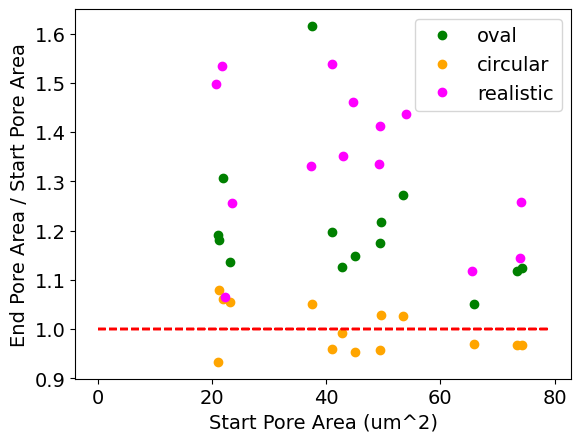

1.53
1.45
1.26
1.46
1.45
1.18
1.39
1.4
1.61
1.33
1.23
1.09
2.14
1.33


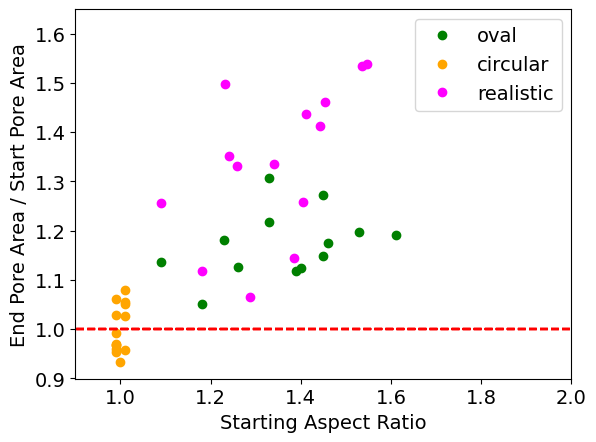

1.53
1.45
1.26
1.46
1.45
1.18
1.39
1.4
1.61
1.33
1.23
1.09
2.14
1.33


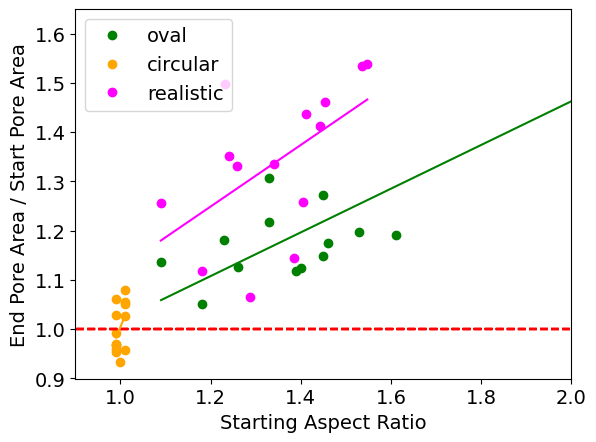

In [265]:
## Figure 3: 
## a) Cross-sectional aspect ratio drives geometry-derived stomatal opening

## Load in the idealised results
df_idealised = pd.read_csv("idealised_results_df.csv")

for mesh in selected_meshes:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = confocal_df[confocal_df["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    if len(idealised_oval_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in idealised oval.")
        continue
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    if len(mesh_data_confocal_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in confocal.")
        continue
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]
    idealised_oval_pore_area_change = (idealised_oval_end["Pore Area (um^2)"].values[0]/ idealised_oval_start["Pore Area (um^2)"].values[0])
    idealised_circular_pore_area_change = (idealised_circular_end["Pore Area (um^2)"].values[0] / idealised_circular_start["Pore Area (um^2)"].values[0])
    confocal_pore_area_change = (mesh_data_confocal_end["Pore Area"].values[0] / mesh_data_confocal_start["Pore Area"].values[0])

    plt.plot(idealised_oval_start["Pore Area (um^2)"].values[0], idealised_oval_pore_area_change, 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_start["Pore Area (um^2)"].values[0], idealised_circular_pore_area_change, 'o', label="circular", color=colours['simplified_circular'])
    plt.plot(mesh_data_confocal_start["Pore Area"].values[0], confocal_pore_area_change, 'o', label="realistic", color=colours['realistic'])
    ## Plot y=1 in red
    xs = np.arange(0,80)
    ys = np.ones(len(xs))
    plt.plot(xs, ys, 'r--', label='y=1')

plt.xlabel("Start Pore Area (um^2)")
plt.ylabel("End Pore Area / Start Pore Area")

# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:3], labels[:3])  # Use only the first three elements

plt.savefig("idealised_confocal_above_one.png", dpi=300)
plt.show()

import re

def extract_float(val):
    # Handles strings like '[np.float64(1.4530883389409186)]'
    import re
    if isinstance(val, str):
        # Match a float inside parentheses after np.float64
        match = re.search(r'np\.float64\(([-+]?[0-9]*\.?[0-9]+)\)', val)
        if match:
            return round(float(match.group(1)), 2)
        # Fallback: match any float number in the string
        match = re.search(r'([-+]?[0-9]*\.?[0-9]+)', val)
        if match:
            return round(float(match.group(1)), 2)
        raise ValueError(f"Could not extract float from {val}")
    else:
        return round(float(val), 2)

# b) Plot starting aspect ratio vs end pore area / start pore area for idealised and confocal
for mesh in selected_meshes:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = confocal_df[confocal_df["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    if len(idealised_oval_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in idealised oval.")
        continue
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    if len(mesh_data_confocal_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in confocal.")
        continue
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]
    idealised_oval_pore_area_change = (idealised_oval_end["Pore Area (um^2)"].values[0]/ idealised_oval_start["Pore Area (um^2)"].values[0])
    idealised_circular_pore_area_change = (idealised_circular_end["Pore Area (um^2)"].values[0] / idealised_circular_start["Pore Area (um^2)"].values[0])
    confocal_pore_area_change = (mesh_data_confocal_end["Pore Area"].values[0] / mesh_data_confocal_start["Pore Area"].values[0])

    idealised_oval_ar = extract_float(idealised_oval_start['Aspect Ratio'].values[0])
    idealised_circular_ar = extract_float(idealised_circular_start['Aspect Ratio'].values[0])
    print(idealised_oval_ar)
    confocal_ar = mesh_data_confocal_start["Midsection AR left"].values[0]
    plt.plot(idealised_oval_ar, idealised_oval_pore_area_change, 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_ar, idealised_circular_pore_area_change, 'o', label="circular", color=colours['simplified_circular'])
    plt.plot(confocal_ar, confocal_pore_area_change, 'o', label="realistic", color=colours['realistic'])
    ## Plot y=1 in red
    xs = np.arange(0,3)
    ys = np.ones(len(xs))
    plt.plot(xs, ys, 'r--', label='y=1')
plt.xlabel("Starting Aspect Ratio")
plt.ylabel("End Pore Area / Start Pore Area")
plt.xlim(0,2.5)
# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:3], labels[:3])  # Use only the first three elements
plt.xlim(0.9, 2.0)
plt.savefig("idealised_confocal_AR_above_one.png", dpi=300)
plt.show()

oval_ars = []
circular_ars = []
confocal_ars = []
oval_changes = []
circular_changes = []
confocal_changes = []

# c) Plot starting aspect ratio vs end pore area / start pore area for idealised and confocal (line of best fit)
for mesh in selected_meshes:
    idealised_oval = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "oval")]
    idealised_circular = df_idealised[(df_idealised["Mesh ID"].str.contains(mesh)) & (df_idealised["Cross-section type"] == "circular")]
    mesh_data_confocal = confocal_df[confocal_df["Mesh ID"].str.contains(mesh)]
    if idealised_oval.empty or mesh_data_confocal.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    idealised_oval_start = idealised_oval[idealised_oval["Pressure (MPa)"] == 0.0]
    if len(idealised_oval_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in idealised oval.")
        continue
    idealised_circular_start = idealised_circular[idealised_circular["Pressure (MPa)"] == 0.0]
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]
    if len(mesh_data_confocal_start) == 0:
        print(f"Skipping mesh {mesh} due to missing start data in confocal.")
        continue
    idealised_oval_end = idealised_oval[idealised_oval["Pressure (MPa)"] == idealised_oval["Pressure (MPa)"].max()]
    idealised_circular_end = idealised_circular[idealised_circular["Pressure (MPa)"] == idealised_circular["Pressure (MPa)"].max()]
    mesh_data_confocal_end = mesh_data_confocal[mesh_data_confocal["Pressure"] == mesh_data_confocal["Pressure"].max()]
    idealised_oval_pore_area_change = (idealised_oval_end["Pore Area (um^2)"].values[0]/ idealised_oval_start["Pore Area (um^2)"].values[0])
    idealised_circular_pore_area_change = (idealised_circular_end["Pore Area (um^2)"].values[0] / idealised_circular_start["Pore Area (um^2)"].values[0])
    confocal_pore_area_change = (mesh_data_confocal_end["Pore Area"].values[0] / mesh_data_confocal_start["Pore Area"].values[0])

    idealised_oval_ar = extract_float(idealised_oval_start['Aspect Ratio'].values[0])
    idealised_circular_ar = extract_float(idealised_circular_start['Aspect Ratio'].values[0])
    print(idealised_oval_ar)
    confocal_ar = mesh_data_confocal_start["Midsection AR left"].values[0]
    plt.plot(idealised_oval_ar, idealised_oval_pore_area_change, 'o', label="oval", color=colours['simplified_oval'])
    plt.plot(idealised_circular_ar, idealised_circular_pore_area_change, 'o', label="circular", color=colours['simplified_circular'])
    plt.plot(confocal_ar, confocal_pore_area_change, 'o', label="realistic", color=colours['realistic'])

    oval_ars.append(idealised_oval_ar)
    circular_ars.append(idealised_circular_ar)
    confocal_ars.append(confocal_ar)
    oval_changes.append(idealised_oval_pore_area_change)
    circular_changes.append(idealised_circular_pore_area_change)
    confocal_changes.append(confocal_pore_area_change)
    ## Plot y=1 in red
    xs = np.arange(0,3)
    ys = np.ones(len(xs))
    plt.plot(xs, ys, 'r--', label='y=1')

from scipy.stats import linregress
import numpy as np

# Example: oval_ars and oval_changes are your x and y values for the oval group
if len(oval_ars) > 1:
    slope, intercept, r, p, stderr = linregress(oval_ars, oval_changes)
    xs = np.linspace(min(oval_ars), max(oval_ars), 100)
    plt.plot(xs, slope*xs + intercept, color=colours['simplified_oval'], linestyle='-', label='Oval fit')

if len(circular_ars) > 1:
    slope, intercept, r, p, stderr = linregress(circular_ars, circular_changes)
    xs = np.linspace(min(circular_ars), max(circular_ars), 100)
    plt.plot(xs, slope*xs + intercept, color=colours['simplified_circular'], linestyle='-', label='Circular fit')

if len(confocal_ars) > 1:
    slope, intercept, r, p, stderr = linregress(confocal_ars, confocal_changes)
    xs = np.linspace(min(confocal_ars), max(confocal_ars), 100)
    plt.plot(xs, slope*xs + intercept, color=colours['realistic'], linestyle='-', label='Realistic fit')

plt.xlabel("Starting Aspect Ratio")
plt.ylabel("End Pore Area / Start Pore Area")
plt.xlim(0,2.5)
# Example: Restrict legend to the first two elements
handles, labels = plt.gca().get_legend_handles_labels()  # Get all handles and labels
plt.legend(handles[:3], labels[:3])  # Use only the first three elements
plt.xlim(0.9, 2.0)
plt.savefig("idealised_confocal_AR_above_one_bf.png", dpi=300)
plt.show()


In [277]:
## Figure 4: Anisotropy
## Plot guard cell length - does this change with inflation?
## Anisotropy - how does this affect opening dynamics?
## Can we show that initial differences in opening are due to geometry, whereas later differences are due to anisotropy?
## Which morphospace do plants need to live in?

import importlib
importlib.reload(csh)
from mesh_functions import process_mesh_pressure
import numpy as np
from concurrent.futures import ProcessPoolExecutor

pressures = np.arange(0, 2.1, 0.1)
midsection_areas = pd.read_csv("midsection_areas.csv")
area_map = {row['mesh_file']: (row['midsection_area1'], row['midsection_area2']) for _, row in midsection_areas.iterrows()}

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    for p in pressures:
        tasks.append((mesh, p, area1, area2))

## Add in the midsection areas for passing to the process_mesh_pressure function

results_matrix = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results = [list(row) for row in results_matrix]
        


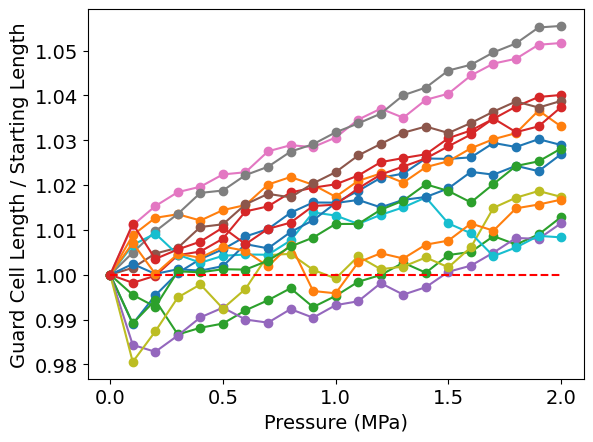

In [278]:
## Plot stomata length vs pressure
for output in results:
    plt.plot(pressures, output / output[0], 'o-')

plt.plot(pressures, np.ones(len(pressures)), 'r--')
plt.xlabel("Pressure (MPa)")
plt.ylabel("Guard Cell Length / Starting Length")
plt.savefig("guard_cell_length_change.png", dpi=300)
plt.show()


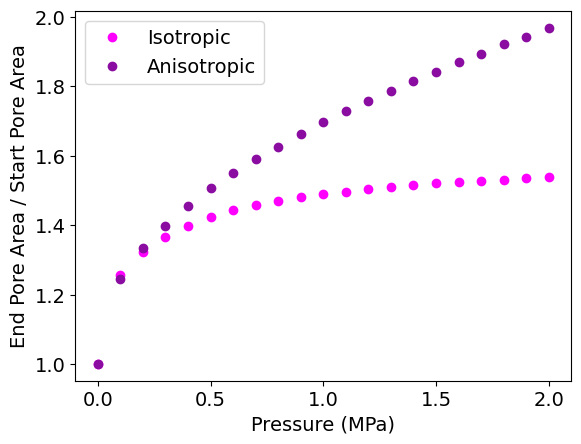

In [279]:
# Plot pressure vs change in pore area for confocal meshes with and without anisotropic stiffening
isotropic_handle = None
anisotropic_handle = None

this_mesh = selected_meshes[0]
for mesh in [this_mesh]:
    mesh_data_confocal = confocal_df[confocal_df["Mesh ID"].str.contains(mesh)]
    mesh_data_confocal_aniso = confocal_df_aniso[confocal_df_aniso["Mesh ID"].str.contains(mesh)]
    if mesh_data_confocal.empty or mesh_data_confocal_aniso.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]["Pore Area"].values[0]
    change_in_pore_area = (mesh_data_confocal["Pore Area"].values / mesh_data_confocal_start)
    h1, = plt.plot(mesh_data_confocal["Pressure"], change_in_pore_area, 'o', color=colours['realistic'], label=None)
    if isotropic_handle is None:
        isotropic_handle = h1
    mesh_data_confocal_aniso_start = mesh_data_confocal_aniso[mesh_data_confocal_aniso["Pressure"] == 0.0]["Pore Area"].values[0]
    change_in_pore_area_aniso = (mesh_data_confocal_aniso["Pore Area"].values / mesh_data_confocal_aniso_start)
    h2, = plt.plot(mesh_data_confocal_aniso["Pressure"], change_in_pore_area_aniso, 'o', color=colours['anisotropic'], label=None)
    if anisotropic_handle is None:
        anisotropic_handle = h2
plt.xlabel("Pressure (MPa)")
plt.ylabel("End Pore Area / Start Pore Area")
plt.legend([isotropic_handle, anisotropic_handle], ["Isotropic", "Anisotropic"] )
plt.savefig("iso_vs_aniso.png", dpi=300)
plt.show()

In [280]:
## Let's visualise changes in pore width due to aspect ratio changes
importlib.reload(csh)

## Load in and view two meshes

mesh_deflated = trimesh.load_mesh("../Meshes/Idealised/pressure_results/idealised_final_1_2_oval_0.0.obj")
mesh_inflated = trimesh.load_mesh("../Meshes/Idealised/pressure_results/idealised_final_1_2_oval_2.0.obj")

## Create mesh inflated trace
mesh_inflated_trace = go.Mesh3d(
            x=mesh_inflated.vertices[:, 0],
            y=mesh_inflated.vertices[:, 1],
            z=mesh_inflated.vertices[:, 2],
            i=mesh_inflated.faces[:, 0],
            j=mesh_inflated.faces[:, 1],
            k=mesh_inflated.faces[:, 2],
            color="#B20012",
            opacity=0.25,
            name='Inflated mesh'
        )

output = csh.visualize_mesh(mesh_deflated, [mesh_inflated_trace], opacity = 0.25)
output.write_html("mesh_comp.html")



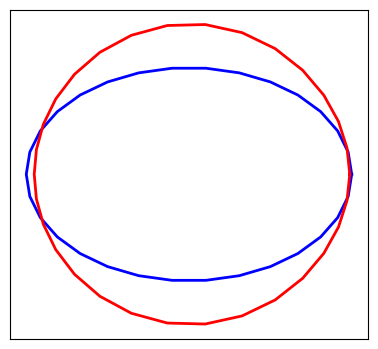

In [281]:
## Look at the cross section of the inflated and uninflated meshes
from sklearn.decomposition import PCA

def get_idealised_midsection(mesh):
    # --- Slice through midplane perpendicular to Y ---
    y_mid = mesh.bounds[:, 1].mean()
    tol = 0.2  # thickness of slice
    midsection_mask = np.abs(mesh.vertices[:, 1] - y_mid) < tol
    midsection_points = mesh.vertices[midsection_mask]

    if len(midsection_points) == 0:
        raise ValueError("No vertices found within midsection tolerance.")

    # --- Cluster into two halves (the two guard cells) ---
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=2, random_state=0).fit(midsection_points)
    labels = kmeans.labels_

    return midsection_points[labels == 0]

## Run for both meshes
mid_deflated = get_idealised_midsection(mesh_deflated)
mid_inflated = get_idealised_midsection(mesh_inflated)

## plot the cross sections
# Project 3D points to 2D using PCA
pca = PCA(n_components=2)
points_2d_deflated = pca.fit_transform(mid_deflated)
points_2d_inflated = pca.fit_transform(mid_inflated)

size_inches = [4,4]

# Create figure with white background
fig, ax = plt.subplots(1, 1, figsize=size_inches, facecolor='white')
ax.set_facecolor('white')

# Close the contour by adding the first point at the end
closed_points_deflated = np.vstack([points_2d_deflated, points_2d_deflated[0]])
closed_points_inflated = np.vstack([points_2d_inflated, points_2d_inflated[0]])

# Plot the cross-section as a black line
ax.plot(closed_points_deflated[:, 0], closed_points_deflated[:, 1], 'b-', linewidth=2)
ax.plot(closed_points_inflated[:, 0], closed_points_inflated[:, 1], 'r-', linewidth=2)

# Set equal aspect ratio and clean up axes
ax.set_aspect('equal')

# Remove axes ticks and labels for clean appearance
ax.set_xticks([])
ax.set_yticks([])

# Tight layout to minimize white space
plt.tight_layout()

plt.savefig("inflated_deflated_cs.png", dpi = 300)
plt.show()



In [211]:
## Look at the cross sectional areas between the tips and the midsections

def parse_points_string(s):
    import re
    import ast
    import numpy as np
    
    # Remove np.str_('...') or np.str_("...") wrapper if present
    s = re.sub(r"^np\.str_\(['\"](.*)['\"]\)$", r"\1", s.strip())
    
    # Replace newlines with spaces
    s = s.replace('\n', ' ')
    
    # Clean each inner bracketed list
    def fix_inner_list(match):
        nums = re.split(r'[\s,]+', match.group(1).strip())
        nums = [n for n in nums if n]
        return '[' + ', '.join(nums) + ']'
    
    # Apply to all inner bracket groups
    s = re.sub(r'\[([^\[\]]+)\]', fix_inner_list, s)
    
    # Insert commas between adjacent lists
    s = re.sub(r'\]\s*\[', '], [', s)
    
    # Remove double spaces and trailing commas
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r',\s*\]', ']', s)
    
    # Parse safely
    points = ast.literal_eval(s)
    return np.array(points, dtype=float)


tip_area = []
mid_area = []

for mesh in selected_meshes:
    df_mesh = confocal_df[(confocal_df["Mesh ID"] == mesh) & (confocal_df["Pressure"] == 0.0)].copy()

    df_mesh["Midsection Points Left"] = df_mesh["Midsection Points Left"].apply(parse_points_string)
    df_mesh["Midsection Points Right"] = df_mesh["Midsection Points Right"].apply(parse_points_string)
    df_mesh["Tip Points Left"] = df_mesh["Tip Points Left"].apply(parse_points_string)
    df_mesh["Tip Points Right"] = df_mesh["Tip Points Right"].apply(parse_points_string)

    mid_area_left = csh.calculate_cross_section_areas(df_mesh["Midsection Points Left"])
    mid_area_right = csh.calculate_cross_section_areas(df_mesh["Midsection Points Right"])

    tip_area_left = csh.calculate_cross_section_areas(df_mesh["Tip Points Left"])
    tip_area_right = csh.calculate_cross_section_areas(df_mesh["Tip Points Right"])

    tip_area.append([tip_area_left, tip_area_right])
    mid_area.append([mid_area_left, mid_area_right])





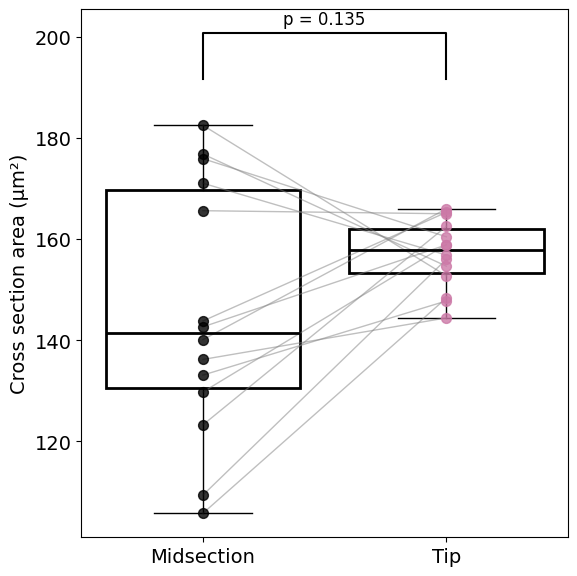

In [227]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, ttest_rel

# ---- Process paired data ----
mid_per_sample = [np.mean([x[0] for x in sample]) for sample in mid_area]
tip_per_sample = [np.mean([x[0] for x in sample]) for sample in tip_area]

# Paired significance test
t_stat, p_t = ttest_rel(mid_per_sample, tip_per_sample)
w_stat, p_w = wilcoxon(mid_per_sample, tip_per_sample)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6, 6))
box_data = [mid_per_sample, tip_per_sample]
labels = ['Midsection', 'Tip']

# Boxplots
bp = ax.boxplot(box_data, positions=[1, 2], widths=0.8, patch_artist=True,
                boxprops=dict(facecolor='white', linewidth=2),
                medianprops=dict(color='black', linewidth=2))

# Overlay paired lines (each sample)
for m, t in zip(mid_per_sample, tip_per_sample):
    ax.plot([1, 2], [m, t], color='gray', alpha=0.5, linewidth=1, zorder=2)

# Scatter points
ax.scatter(np.full(len(mid_per_sample), 1), mid_per_sample,
           color=colours["midsection"], alpha=0.8, s=50, zorder=3, label='Midsection')
ax.scatter(np.full(len(tip_per_sample), 2), tip_per_sample,
           color=colours["tip"], alpha=0.8, s=50, zorder=3, label='Tip')

# Axis labels
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_ylabel('Cross section area (µm²)')

# ---- Add significance bar ----
y_max = max(max(mid_per_sample), max(tip_per_sample))
h = (y_max * 0.05)  # height offset for the bar
bar_y = y_max + h

# Draw the horizontal bar
ax.plot([1, 1, 2, 2], [bar_y, bar_y + h, bar_y + h, bar_y], lw=1.5, color='black')

# Add the p-value text
text_y = bar_y + h * 1.1
p_text = f"p = {p_w:.3g}" if p_w >= 0.001 else "p < 0.001"
ax.text(1.5, text_y, p_text, ha='center', va='bottom', fontsize=12)

# Clean up layout
plt.tight_layout()
plt.savefig("cross_section_area_bpx.png", dpi = 300)
plt.show()


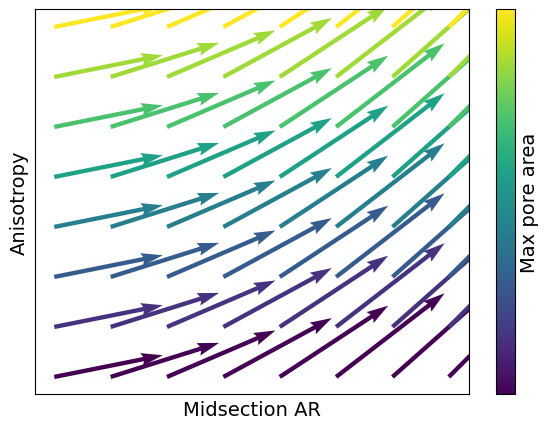

In [257]:
import numpy as np
import matplotlib.pyplot as plt

# Denser conceptual grid for more arrows
nx, ny = 8, 8
X, Y = np.meshgrid(np.linspace(0,1,nx), np.linspace(0,1,ny))

# Conceptual slopes: sensitivity increases with aspect ratio (X)
U = np.ones_like(X)            # base horizontal component
V = 0.2 + 0.8*X                # vertical component increases with aspect ratio

# Color represents max aperture increasing with anisotropy (Y)
aperture = 0.2 + 0.8*Y         # conceptual colormap values

plt.figure(figsize=(7,5))
q = plt.quiver(
    X, Y, U, V, aperture, 
    scale=4,        # smaller arrows
    cmap='viridis', 
    width=0.010     # thinner arrows
)

plt.xlabel('Midsection AR')
plt.ylabel('Anisotropy')

# Remove numeric ticks
plt.xticks([])
plt.yticks([])

# Colorbar without numbers
cbar = plt.colorbar(q, label='Max pore area')
cbar.set_ticks([])  # removes numbers

plt.savefig("concept.png",dpi=300)
plt.show()



